# XLRanker Jupyter Notebook

This Jupyter Notebook provides an example of how to start from a peptide network to the final protein network that can be used for functional analysis.

## Example Dataset

The example data used in this notebook is from HEK293 cell lines. The PPI-XL data was taken from https://pubs.acs.org/doi/10.1021/acs.analchem.1c04485, and the protein data was from https://www.ebi.ac.uk/pride/archive/projects/PXD052801. The notebook handles downloading the data to this instance.

### Data Citations

```txt
Combining Quantitative Proteomics and Interactomics for a Deeper Insight into Molecular Differences between Human Cell Lines Anna A. Bakhtina, Helisa H. Wippel, Juan D. Chavez, and James E. Bruce Journal of Proteome Research 2024 23 (12), 5360-5371 DOI: 10.1021/acs.jproteome.4c00503 
Jiao F, Yu C, Wheat A, Wang X, Rychnovsky SD, Huang L. Two-Dimensional Fractionation Method for Proteome-Wide Cross-Linking Mass Spectrometry Analysis. Anal Chem. 2022 Mar 15;94(10):4236-4242. doi: 10.1021/acs.analchem.1c04485. Epub 2022 Mar 2. PMID: 35235311; PMCID: PMC9056026.
```

## Install xlranker

If `xlranker` is not already installed, run the below command

In [1]:
%pip install xlranker # install xlranker

/Users/johnelizarraras/Code/ppi_xl/xlranker/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Data Download

In [2]:
import tarfile
from io import BytesIO

import requests

# Download the example data
url = "https://github.com/bzhanglab/xlranker/raw/refs/heads/master/notebooks/downloads/example_data.tar.gz"
response = requests.get(url)
response.raise_for_status()

# Open the tar.gz file and save to /content/
with tarfile.open(fileobj=BytesIO(response.content), mode="r:gz") as tar:
    tar.extractall(path="content/")
    print("Files extracted to /content/")

Files extracted to /content/


## Getting Started

In [ ]:
import xlranker
from xlranker.config import config as xlranker_config
from xlranker.util.mapping import FastaType, PeptideMapper

xlranker_config.reduce_fasta = False  # Only accept the longest sequence
xlranker_config.output = "xlranker_output/"  # output folder


xlranker.lib.setup_logging()  # enable logging

xlranker.util.set_seed(10)  # set seed for reproducibility (optional)

mapper = PeptideMapper(
    mapping_table_path="content/human_2019_04.fasta",
    is_fasta=True,
    fasta_type=FastaType.UNIPROT,
)  # Use custom mapping table from UNIPROT

data_set = xlranker.lib.XLDataSet.load_from_network(
    "content/init_network.tsv", "content/omic_data/", custom_mapper=mapper
)


data_set.build_proteins(remove_intra=False)
print(f"Identified {len(data_set.protein_pairs)} pairs")
uniq_prots = set()
for pair in data_set.protein_pairs.values():
    uniq_prots.add(pair.a.name)
    uniq_prots.add(pair.b.name)
print(f"Identified {len(uniq_prots)} unique proteins")
from xlranker.lib import XLDataSet, get_final_network
from xlranker.ml.models import PrioritizationModel
from xlranker.parsimony.prioritize import ParsimonySelector, select_random
from xlranker.selection import ThresholdSelector
from xlranker.report import make_all_reports

parsimony = ParsimonySelector(data_set)
parsimony.run()
model = PrioritizationModel(data_set)
model.run_model()
get_final_network(data_set, ThresholdSelector(0.5))
make_all_reports(list(data_set.protein_pairs.values()))

[INFO] Using custom fasta file for peptide mapping
[WARNING] Found and removed 2864 duplicated edge(s) in network.
[INFO] Mapping 10388 peptide sequences


Identified 8779 pairs
Identified 4753 unique proteins


[INFO] Model on run 1/10
[INFO] ROC AUC for run 1: 0.98
[INFO] Model on run 2/10
[INFO] ROC AUC for run 2: 0.98
[INFO] Model on run 3/10
[INFO] ROC AUC for run 3: 0.97
[INFO] Model on run 4/10
[INFO] ROC AUC for run 4: 0.98
[INFO] Model on run 5/10
[INFO] ROC AUC for run 5: 0.98
[INFO] Model on run 6/10
[INFO] ROC AUC for run 6: 0.98
[INFO] Model on run 7/10
[INFO] ROC AUC for run 7: 0.98
[INFO] Model on run 8/10
[INFO] ROC AUC for run 8: 0.98
[INFO] Model on run 9/10
[INFO] ROC AUC for run 9: 0.98
[INFO] Model on run 10/10
[INFO] ROC AUC for run 10: 0.98
[INFO] Average AUC across 10 runs: 0.9779 ± 0.0021
[INFO] Results saved to: .


/Users/johnelizarraras/Code/ppi_xl/xlranker/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


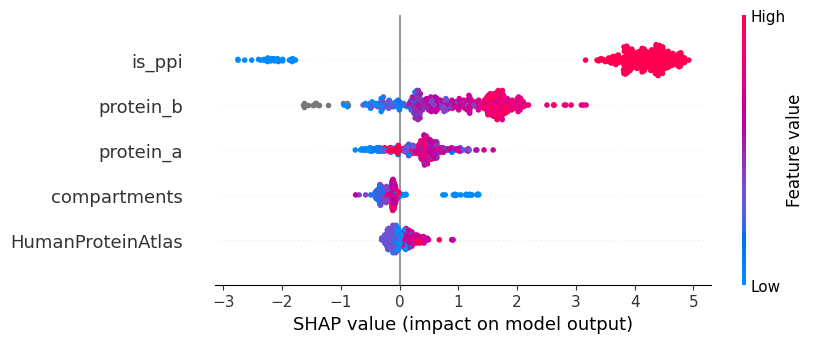

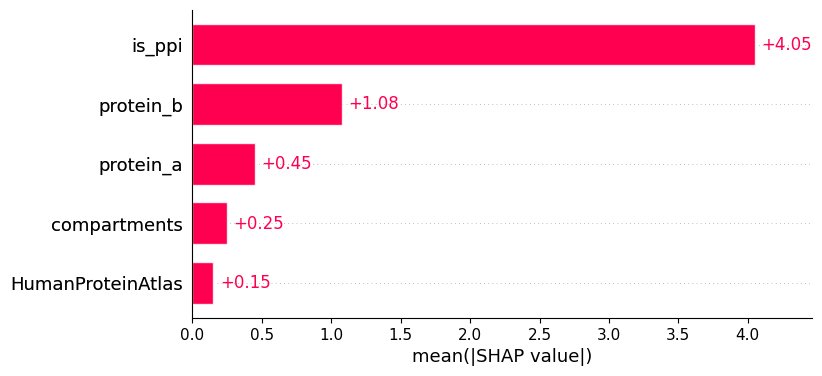

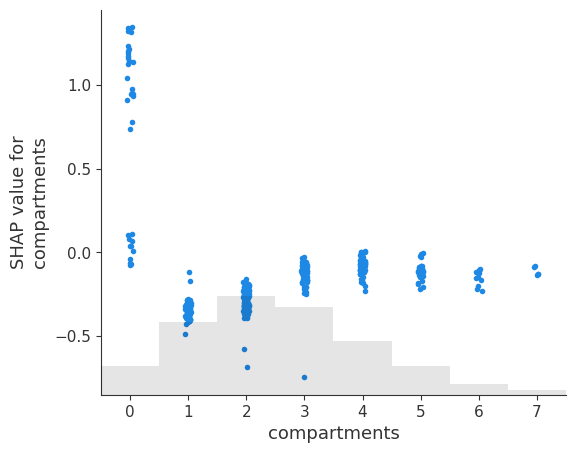

In [4]:
import shap
import polars as pl

make_all_reports(list(data_set.protein_pairs.values()))
data_path = "xlranker_output/training_positives.tsv"

df = pl.read_csv(data_path, separator="\t")
models = model.xgboost_models

# get mean shap values across all models
shap_values_list = []
for m in models:
    explainer = shap.Explainer(m)
    shap_values = explainer(df.drop(["pair", "label"]).to_pandas())
    shap_values_list.append(shap_values.values)
shap_values_mean = sum(shap_values_list) / len(shap_values_list)

shap_values = shap.Explanation(
    values=shap_values_mean,
    data=df.drop(["pair", "label"]).to_pandas().values,
    feature_names=df.drop(["pair", "label"]).columns,
)
## plot

# shap_values = explainer(df.drop(["pair", "prediction"]).to_pandas())
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)
# shap.plots.heatmap(shap_values, max_display=20)
shap.plots.scatter(shap_values[:, "compartments"])

## Analysis

One key point to evaluate the performance of xlranker's model is by looking at the separation between the prioritized and unprioritized pairs.

To create a chart, install `pandas` and `seaborn`

In [5]:
%pip install pandas seaborn scipy # Install if not done already

/Users/johnelizarraras/Code/ppi_xl/xlranker/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


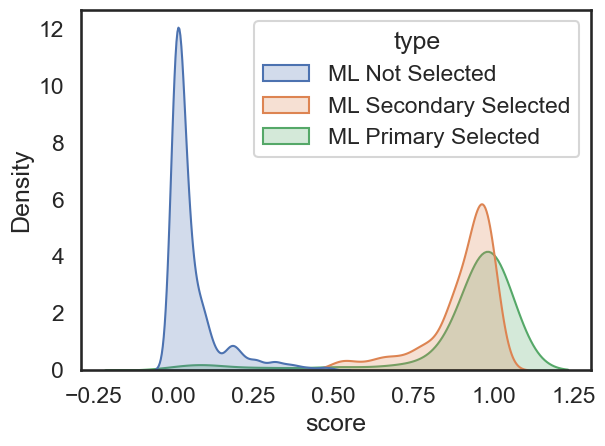

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from xlranker.status import PrioritizationStatus

df_dict = {"type": [], "score": []}

for pair in data_set.protein_pairs.values():
    if pair.prioritization_status == PrioritizationStatus.ML_PRIMARY_SELECTED:
        df_dict["type"].append("ML Primary Selected")
        df_dict["score"].append(pair.score)
    elif pair.prioritization_status == PrioritizationStatus.ML_SECONDARY_SELECTED:
        df_dict["type"].append("ML Secondary Selected")
        df_dict["score"].append(pair.score)
    elif pair.prioritization_status == PrioritizationStatus.ML_NOT_SELECTED:
        df_dict["type"].append("ML Not Selected")
        df_dict["score"].append(pair.score)

df = pd.DataFrame(df_dict)
sns.set_theme(context="talk", style="white")
sns.kdeplot(df, hue="type", x="score", fill=True, common_norm=False)
plt.tight_layout()
plt.show()